# 02. Classical Models

This notebook rebuilds the classical-model study from raw data rather than leaning on the old saved artifact. The purpose is to establish interpretable point-forecast baselines, test whether target history alone is enough, and show clearly where classical methods fail before the project moves to global ML models.

**Executive summary**
- The notebook reruns all selected classical models directly from raw train data with a temporal validation split at `VAL_CUTOFF = 2880`.
- The lineup drops `Zero` and adds `Rolling Mean`, `Mean Reversion`, and `AR`, alongside `Naive`, `Drift`, `Expanding Mean`, `ETS`, and `ARIMA`.
- The notebook records failures and skips explicitly so averages do not hide which classical methods break on short or unstable series.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path('../data/ts-forecasting')
VAL_CUTOFF = 2880
ROLLING_WINDOW = 10
MEAN_REVERSION_DECAY = 0.5
MAX_AR_LAG = 5
ARIMA_ORDERS = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (0, 0, 1)]

train = pd.read_parquet(DATA_DIR / 'train.parquet', columns=['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight'])
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / denom))

def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / denom)

def get_series_df(meta_row):
    mask = (
        (train['code'] == meta_row.code)
        & (train['sub_code'] == meta_row.sub_code)
        & (train['sub_category'] == meta_row.sub_category)
        & (train['horizon'] == meta_row.horizon)
    )
    return train.loc[mask, ['ts_index', 'y_target', 'weight']].sort_values('ts_index').reset_index(drop=True)

def split_series(series_df):
    train_part = series_df[series_df['ts_index'] <= VAL_CUTOFF].copy()
    val_part = series_df[series_df['ts_index'] > VAL_CUTOFF].copy()
    return train_part, val_part

def forecast_naive(y_train, steps):
    return np.repeat(float(y_train.iloc[-1]), steps)

def forecast_drift(y_train, steps):
    if len(y_train) < 2:
        raise ValueError('need at least 2 observations')
    slope = (float(y_train.iloc[-1]) - float(y_train.iloc[0])) / (len(y_train) - 1)
    return float(y_train.iloc[-1]) + slope * np.arange(1, steps + 1)

def forecast_expanding_mean(y_train, steps):
    return np.repeat(float(y_train.mean()), steps)

def forecast_rolling_mean(y_train, steps, window=ROLLING_WINDOW):
    return np.repeat(float(y_train.iloc[-min(window, len(y_train)):].mean()), steps)

def forecast_mean_reversion(y_train, steps, decay=MEAN_REVERSION_DECAY):
    mean_val = float(y_train.mean())
    last_val = float(y_train.iloc[-1])
    horizons = np.arange(1, steps + 1)
    return mean_val + (last_val - mean_val) * (decay ** horizons)

def forecast_autoreg(y_train, steps, max_lag=MAX_AR_LAG):
    candidate_max = min(max_lag, max(1, len(y_train) // 3), len(y_train) - 1)
    if candidate_max < 1:
        raise ValueError('series too short for AR')
    best_fit = None
    best_aic = np.inf
    for lag in range(1, candidate_max + 1):
        try:
            fit = AutoReg(y_train, lags=lag, old_names=False, trend='c').fit()
            if np.isfinite(fit.aic) and fit.aic < best_aic:
                best_fit = fit
                best_aic = fit.aic
        except Exception:
            continue
    if best_fit is None:
        raise ValueError('AutoReg failed for all candidate lags')
    pred = best_fit.predict(start=len(y_train), end=len(y_train) + steps - 1, dynamic=False)
    return np.asarray(pred, dtype=float), {'selected_lag': int(best_fit.model._k_ar), 'aic': float(best_aic)}

def forecast_ets(y_train, steps):
    fit = ExponentialSmoothing(y_train, trend='add', seasonal=None, initialization_method='estimated').fit(optimized=True)
    pred = fit.forecast(steps)
    return np.asarray(pred, dtype=float), {'sse': float(getattr(fit, 'sse', np.nan))}

def forecast_arima(y_train, steps, orders=ARIMA_ORDERS):
    best_fit = None
    best_order = None
    best_aic = np.inf
    for order in orders:
        try:
            fit = ARIMA(y_train, order=order, enforce_stationarity=False, enforce_invertibility=False).fit()
            if np.isfinite(fit.aic) and fit.aic < best_aic:
                best_fit = fit
                best_order = order
                best_aic = fit.aic
        except Exception:
            continue
    if best_fit is None:
        raise ValueError('ARIMA failed for all candidate orders')
    pred = best_fit.forecast(steps)
    return np.asarray(pred, dtype=float), {'selected_order': best_order, 'aic': float(best_aic)}

MODEL_SPECS = {
    'Naive': {'min_train_len': 1, 'func': lambda y, steps: (forecast_naive(y, steps), {})},
    'Drift': {'min_train_len': 2, 'func': lambda y, steps: (forecast_drift(y, steps), {})},
    'Expanding Mean': {'min_train_len': 1, 'func': lambda y, steps: (forecast_expanding_mean(y, steps), {})},
    'Rolling Mean': {'min_train_len': 2, 'func': lambda y, steps: (forecast_rolling_mean(y, steps), {'window': int(min(ROLLING_WINDOW, len(y)))} )},
    'Mean Reversion': {'min_train_len': 2, 'func': lambda y, steps: (forecast_mean_reversion(y, steps), {'decay': float(MEAN_REVERSION_DECAY)})},
    'AR': {'min_train_len': 25, 'func': forecast_autoreg},
    'ETS': {'min_train_len': 20, 'func': forecast_ets},
    'ARIMA': {'min_train_len': 25, 'func': forecast_arima},
}

train.head()


,code,sub_code,sub_category,horizon,ts_index,y_target,weight
0,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,-0.551324,40.982572
1,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,-0.315583,150.075406
2,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,-0.362894,115.953552
3,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,-0.667023,64.573073
4,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,-0.437398,41.948761


## 1. Why classical models still matter

Classical models are not expected to beat the later global ML notebook, but they are still important. They tell us how much signal lives in target history alone, whether persistence dominates, and whether more complex methods are earning their extra complexity.


**Model lineup in this notebook**

- `Naive`: repeat the last observed target value.
- `Drift`: extend a straight line from the first to the last training value.
- `Expanding Mean`: forecast the global training mean.
- `Rolling Mean`: forecast the mean of the most recent fixed window.
- `Mean Reversion`: move the last value back toward the historical mean with fixed decay.
- `AR`: choose a small autoregressive lag order by AIC.
- `ETS`: additive trend exponential smoothing without seasonality.
- `ARIMA`: choose from a small fixed candidate order set by AIC.


## 2. Series eligibility and evaluation design

We only evaluate series that cross the validation cutoff so every model is judged on post-cutoff observations. Heavier models also need minimum training history; those rules are explicit and later appear in the skip/failure analysis.


In [2]:
series_meta = (
    train.groupby(series_keys)['ts_index']
         .agg(min='min', max='max', count='count')
         .reset_index()
)
series_meta['crosses_cutoff'] = (series_meta['min'] <= VAL_CUTOFF) & (series_meta['max'] > VAL_CUTOFF)
eligible_meta = series_meta[series_meta['crosses_cutoff']].copy()

summary = {
    'total_series': int(len(series_meta)),
    'eligible_series': int(len(eligible_meta)),
    'rows_pre_cutoff': int((train['ts_index'] <= VAL_CUTOFF).sum()),
    'rows_post_cutoff': int((train['ts_index'] > VAL_CUTOFF).sum()),
}
summary


{'total_series': 36923,
 'eligible_series': 1930,
 'rows_pre_cutoff': 4121749,
 'rows_post_cutoff': 1215665}

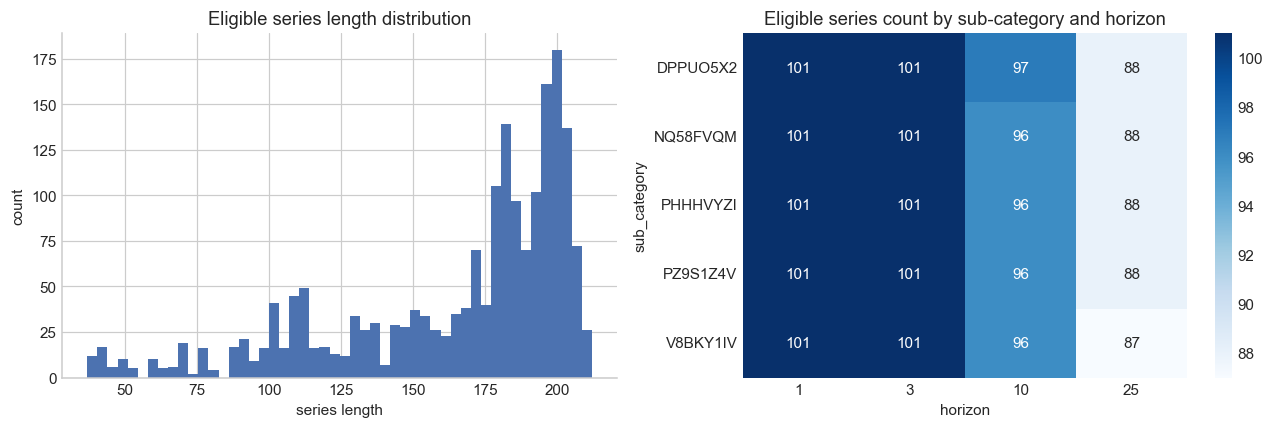

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(eligible_meta['count'], bins=50, color='#4C72B0')
axes[0].set_title('Eligible series length distribution')
axes[0].set_xlabel('series length')
axes[0].set_ylabel('count')

eligibility_table = eligible_meta.groupby(['sub_category', 'horizon']).size().unstack(fill_value=0)
sns.heatmap(eligibility_table, annot=True, fmt='g', cmap='Blues', ax=axes[1])
axes[1].set_title('Eligible series count by sub-category and horizon')
plt.tight_layout()
plt.show()


The classical notebook is not scoring every possible panel series; it is scoring every series that actually permits a temporal validation check. That distinction matters because many short or one-sided series cannot support meaningful post-cutoff evaluation.


## 3. Full rerun evaluation

We evaluate every eligible series across the full classical lineup. Each model either returns a forecast and weighted metrics or records an explicit skip/failure reason.


In [4]:
results = []

for idx, meta_row in enumerate(eligible_meta.itertuples(index=False), start=1):
    series_df = get_series_df(meta_row)
    train_part, val_part = split_series(series_df)
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    steps = len(val_part)
    series_name = f"{meta_row.code}_{meta_row.sub_code}_H{meta_row.horizon}"

    for model_name, spec in MODEL_SPECS.items():
        row = {
            'series': series_name,
            'code': meta_row.code,
            'sub_code': meta_row.sub_code,
            'sub_category': meta_row.sub_category,
            'horizon': int(meta_row.horizon),
            'train_len': int(len(y_train)),
            'val_len': int(steps),
            'model': model_name,
            'status': 'ok',
            'skip_reason': None,
        }
        if len(y_train) < spec['min_train_len']:
            row.update({'status': 'skipped', 'skip_reason': f"train_len<{spec['min_train_len']}"})
            results.append(row)
            continue
        try:
            pred, meta = spec['func'](y_train, steps)
            pred = np.asarray(pred, dtype=float)
            row.update({
                'skill_score': weighted_skill(y_val, pred, w_val),
                'rmse': weighted_rmse(y_val, pred, w_val),
                'mae': weighted_mae(y_val, pred, w_val),
                'model_meta': str(meta),
            })
        except Exception as e:
            row.update({'status': 'failed', 'skip_reason': type(e).__name__})
        results.append(row)

    if idx % 250 == 0:
        print(f'Processed {idx}/{len(eligible_meta)} eligible series')

results = pd.DataFrame(results)
results.head()


Processed 250/1930 eligible series


Processed 500/1930 eligible series


Processed 750/1930 eligible series


Processed 1000/1930 eligible series


Processed 1250/1930 eligible series


Processed 1500/1930 eligible series


Processed 1750/1930 eligible series


,series,code,sub_code,sub_category,horizon,train_len,val_len,model,status,skip_reason,skill_score,rmse,mae,model_meta
0,10BAVIDU_83FRDKQ1_H1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,24,130,Naive,ok,NaN,0.026830,1.646325,1.069516,{}
1,10BAVIDU_83FRDKQ1_H1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,24,130,Drift,ok,NaN,0.000000,1.689653,1.124330,{}
2,10BAVIDU_83FRDKQ1_H1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,24,130,Expanding Mean,ok,NaN,0.028601,1.646245,1.069408,{}
3,10BAVIDU_83FRDKQ1_H1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,24,130,Rolling Mean,ok,NaN,0.000000,1.838524,1.335251,{'window': 10}
4,10BAVIDU_83FRDKQ1_H1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,24,130,Mean Reversion,ok,NaN,0.028595,1.646245,1.069410,{'decay': 0.5}


## 4. Overall leaderboard

Mean skill alone is not enough because it can hide unstable models. We summarize each model with average skill, median skill, positive-skill hit rate, and the number of successful fits.


In [5]:
valid_results = results[results['status'] == 'ok'].copy()
leaderboard = (
    valid_results.groupby('model')
                 .agg(
                     series_evaluated=('series', 'count'),
                     mean_skill=('skill_score', 'mean'),
                     median_skill=('skill_score', 'median'),
                     positive_skill_share=('skill_score', lambda s: float((s > 0).mean())),
                     mean_rmse=('rmse', 'mean'),
                     mean_mae=('mae', 'mean'),
                 )
                 .sort_values('mean_skill', ascending=False)
)
leaderboard


,series_evaluated,mean_skill,median_skill,positive_skill_share,mean_rmse,mean_mae
model,,,,,,
ARIMA,1630,0.133781,0.0,0.392025,144567.971279,40236.132683
AR,1630,0.133583,0.0,0.394479,8.796838,6.564063
Mean Reversion,1905,0.113357,0.0,0.375853,8.175501,6.549602
Rolling Mean,1905,0.107827,0.0,0.321260,7.984970,6.307680
Naive,1930,0.099309,0.0,0.244560,8.486322,6.861381
ETS,1725,0.095897,0.0,0.219710,14.871469,12.590353
Expanding Mean,1930,0.095785,0.0,0.351813,8.390157,6.835502
Drift,1905,0.082275,0.0,0.166404,13.872798,11.830644


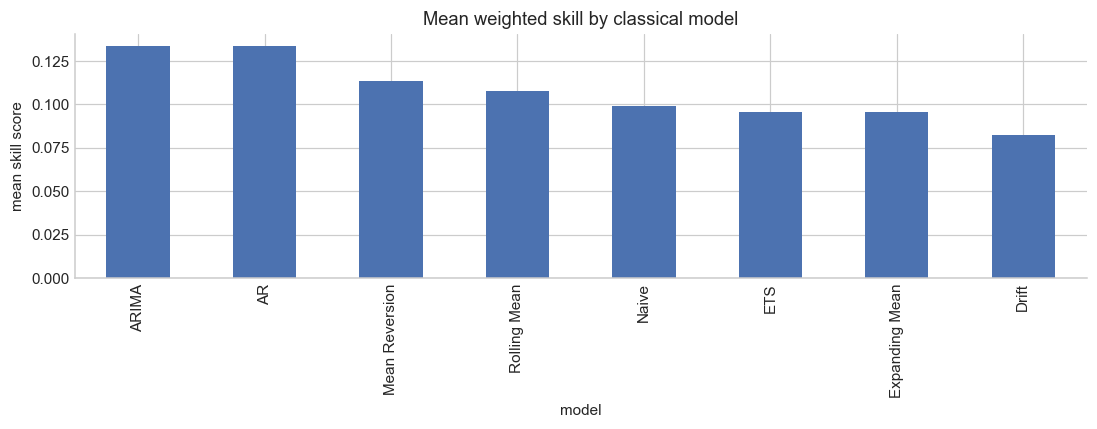

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
leaderboard['mean_skill'].plot.bar(ax=ax, color='#4C72B0')
ax.set_title('Mean weighted skill by classical model')
ax.set_ylabel('mean skill score')
plt.tight_layout()
plt.show()


This is the classical ranking that matters. The notebook should comment on both average skill and hit rate, because a model that wins only in a few series but collapses elsewhere is a weak baseline for the later project story.


## 5. Breakdown by horizon

Classical models usually degrade as forecast horizon grows. We check that explicitly with horizon-level summaries built from the rerun results.


In [7]:
horizon_summary = (
    valid_results.groupby(['horizon', 'model'])['skill_score']
                 .mean()
                 .unstack('model')
                 .sort_index()
)
horizon_summary


model,AR,ARIMA,Drift,ETS,Expanding Mean,Mean Reversion,Naive,Rolling Mean
horizon,,,,,,,,
1,0.057072,0.056860,0.027640,0.044423,0.046355,0.045508,0.032315,0.047907
3,0.096809,0.101639,0.058778,0.072323,0.074192,0.088859,0.065733,0.085514
10,0.171662,0.170672,0.087692,0.090969,0.113708,0.147187,0.100927,0.116507
25,0.224935,0.221471,0.167327,0.190354,0.157849,0.183452,0.213225,0.194040


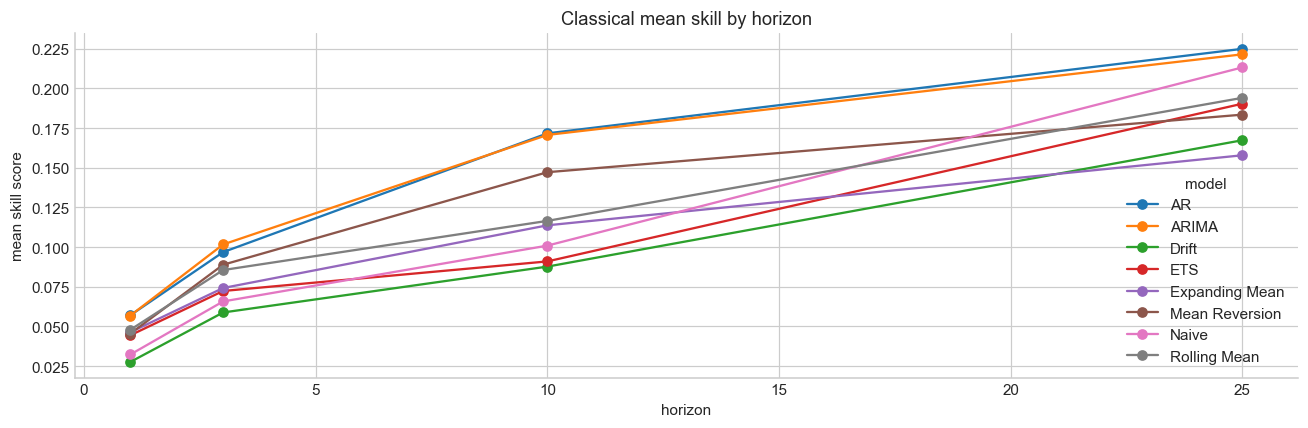

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
horizon_summary.plot(marker='o', ax=ax)
ax.set_title('Classical mean skill by horizon')
ax.set_xlabel('horizon')
ax.set_ylabel('mean skill score')
plt.tight_layout()
plt.show()


## 6. Breakdown by sub-category

We also check whether any classical model is only useful in particular sub-categories rather than generally reliable across the panel.


In [9]:
subcat_summary = (
    valid_results.groupby(['sub_category', 'model'])['skill_score']
                 .mean()
                 .unstack('model')
)
subcat_summary


model,AR,ARIMA,Drift,ETS,Expanding Mean,Mean Reversion,Naive,Rolling Mean
sub_category,,,,,,,,
DPPUO5X2,0.108606,0.108221,0.074192,0.087619,0.066395,0.089572,0.083020,0.086200
NQ58FVQM,0.132232,0.132147,0.075089,0.088874,0.115437,0.127227,0.088360,0.119019
PHHHVYZI,0.128316,0.126321,0.082872,0.092233,0.065959,0.090486,0.099060,0.102086
PZ9S1Z4V,0.118456,0.120281,0.084400,0.098259,0.068360,0.088092,0.107860,0.095575
V8BKY1IV,0.180524,0.182161,0.094877,0.112573,0.163027,0.171624,0.118335,0.136387


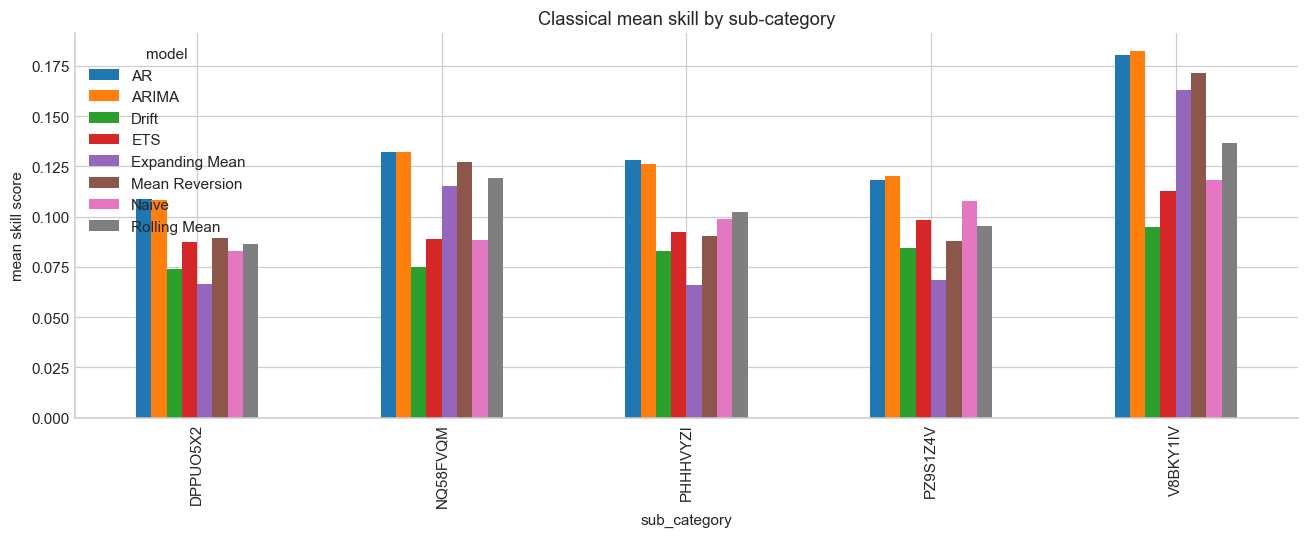

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
subcat_summary.plot.bar(ax=ax)
ax.set_title('Classical mean skill by sub-category')
ax.set_ylabel('mean skill score')
plt.tight_layout()
plt.show()


## 7. Failure and skip analysis

The old notebook hid an important fact: classical models do not just perform differently, they also fail differently. This section makes fit coverage explicit.


In [11]:
status_counts = results.groupby(['model', 'status']).size().unstack(fill_value=0)
status_counts


status,ok,skipped
model,,
AR,1630,300
ARIMA,1630,300
Drift,1905,25
ETS,1725,205
Expanding Mean,1930,0
Mean Reversion,1905,25
Naive,1930,0
Rolling Mean,1905,25


In [12]:
problem_reasons = (
    results[results['status'] != 'ok']
           .groupby(['model', 'status', 'skip_reason'])
           .size()
           .reset_index(name='count')
           .sort_values(['model', 'count'], ascending=[True, False])
)
problem_reasons.head(20)


,model,status,skip_reason,count
0,AR,skipped,train_len<25,300
1,ARIMA,skipped,train_len<25,300
2,Drift,skipped,train_len<2,25
3,ETS,skipped,train_len<20,205
4,Mean Reversion,skipped,train_len<2,25
5,Rolling Mean,skipped,train_len<2,25


This section should explain whether poor results are genuine forecasting weakness, fitting instability, or simple history-length constraints. That distinction matters when we compare classical methods to global ML later.


## 8. Representative series case studies

We choose four series to show where classical models work and where they fail: a best classical case, a worst classical case, a volatile series, and a stable series.


In [13]:
series_best = (
    valid_results.groupby('series')['skill_score']
                 .max()
                 .reset_index(name='best_skill')
)
series_lookup = eligible_meta.copy()
series_lookup['series'] = series_lookup.apply(lambda r: f"{r['code']}_{r['sub_code']}_H{r['horizon']}", axis=1)
series_lookup = series_lookup.merge(series_best, on='series', how='left')

stats = (
    train.groupby(series_keys)
         .agg(target_std=('y_target', 'std'))
         .reset_index()
)
stats['series'] = stats.apply(lambda r: f"{r['code']}_{r['sub_code']}_H{r['horizon']}", axis=1)
series_lookup = series_lookup.merge(stats[['series', 'target_std']], on='series', how='left')

case_rows = pd.concat([
    series_lookup.nlargest(1, 'best_skill').assign(case='best classical case'),
    series_lookup.nsmallest(1, 'best_skill').assign(case='worst classical case'),
    series_lookup.nlargest(1, 'target_std').assign(case='most volatile series'),
    series_lookup.nsmallest(1, 'target_std').assign(case='most stable series'),
], ignore_index=True).drop_duplicates(subset='series')
case_rows[['case', 'series', 'best_skill', 'target_std']]


,case,series,best_skill,target_std
0,best classical case,CXEQN6KB_ZT5R1WKA_H25,0.999899,0.075377
1,worst classical case,1HEMHZK2_OYJGNSQK_H1,0.000000,0.002995
2,most volatile series,W4S29LF4_KL66VIS3_H25,0.936875,296.760011
3,most stable series,83EG83KQ_CUXV51HW_H1,0.898659,0.000055


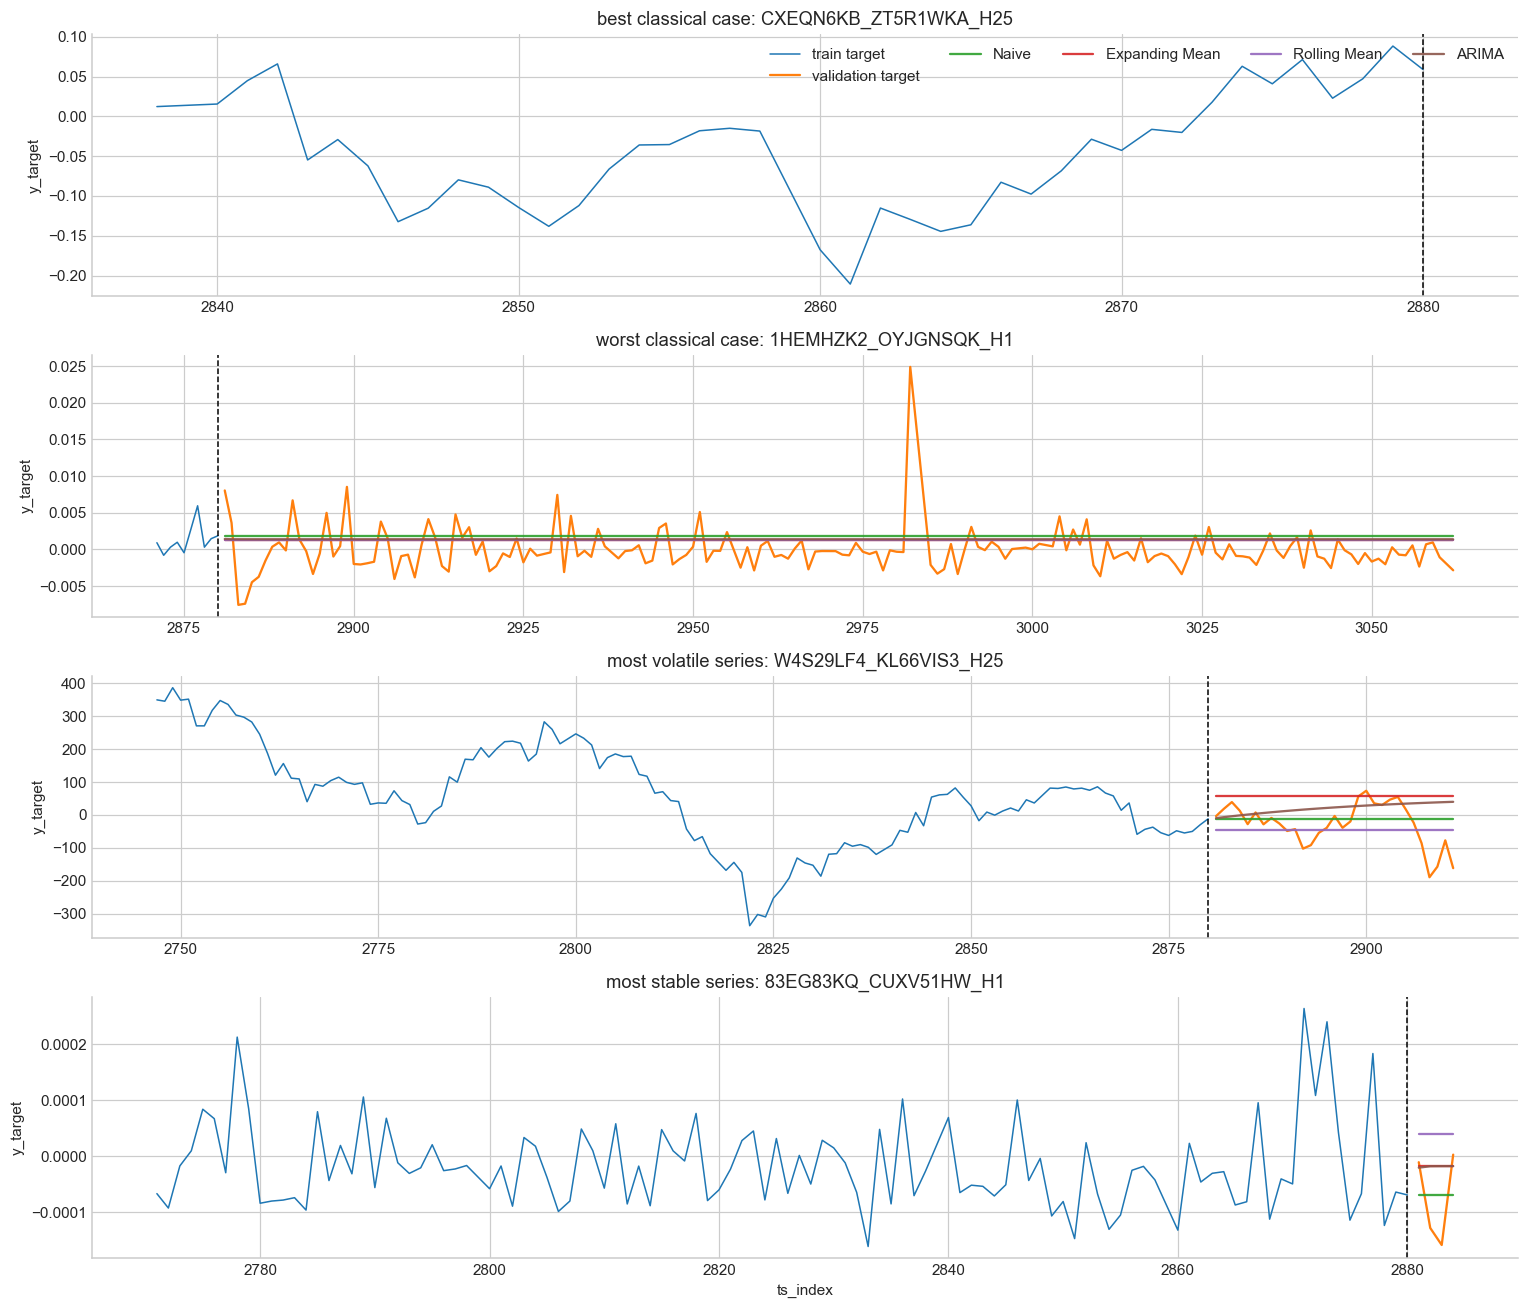

In [14]:
def forecast_for_case(meta_row, model_name):
    series_df = get_series_df(meta_row)
    train_part, val_part = split_series(series_df)
    y_train = train_part['y_target'].reset_index(drop=True)
    steps = len(val_part)
    pred, _ = MODEL_SPECS[model_name]['func'](y_train, steps)
    return train_part, val_part, np.asarray(pred, dtype=float)

plot_models = ['Naive', 'Expanding Mean', 'Rolling Mean', 'ARIMA']
fig, axes = plt.subplots(len(case_rows), 1, figsize=(14, 12), sharex=False)
axes = np.atleast_1d(axes)
for ax, meta_row in zip(axes, case_rows.itertuples(index=False)):
    train_part, val_part = split_series(get_series_df(meta_row))
    ax.plot(train_part['ts_index'], train_part['y_target'], label='train target', linewidth=1)
    ax.plot(val_part['ts_index'], val_part['y_target'], label='validation target', linewidth=1.5)
    for model_name in plot_models:
        try:
            _, _, pred = forecast_for_case(meta_row, model_name)
            ax.plot(val_part['ts_index'], pred, label=model_name, alpha=0.9)
        except Exception:
            continue
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{meta_row.case}: {meta_row.series}")
    ax.set_ylabel('y_target')
axes[-1].set_xlabel('ts_index')
axes[0].legend(loc='upper right', ncol=5)
plt.tight_layout()
plt.show()


These examples should make the classical story visible: where persistence-type rules are enough, where they oversmooth, and where even more structured ARIMA-style fits still fail to track validation dynamics.


## 9. Residual diagnostics for the best classical models

We take the top two models from the rerun leaderboard and inspect their row-level residual distributions on a subset of series.


In [15]:
top_models = leaderboard.head(2).index.tolist()
residual_rows = []
for model_name in top_models:
    for meta_row in eligible_meta.head(300).itertuples(index=False):
        if len(split_series(get_series_df(meta_row))[0]) < MODEL_SPECS[model_name]['min_train_len']:
            continue
        try:
            train_part, val_part = split_series(get_series_df(meta_row))
            pred, _ = MODEL_SPECS[model_name]['func'](train_part['y_target'].reset_index(drop=True), len(val_part))
            tmp = pd.DataFrame({
                'model': model_name,
                'residual': val_part['y_target'].to_numpy(dtype=float) - np.asarray(pred, dtype=float),
                'weight': val_part['weight'].to_numpy(dtype=float),
            })
            residual_rows.append(tmp)
        except Exception:
            continue
residual_df = pd.concat(residual_rows, ignore_index=True)
residual_df.head()


,model,residual,weight
0,ARIMA,-0.396243,0.910709
1,ARIMA,1.874744,0.920299
2,ARIMA,-2.543862,0.914487
3,ARIMA,-0.432146,0.914699
4,ARIMA,-0.098842,0.925002


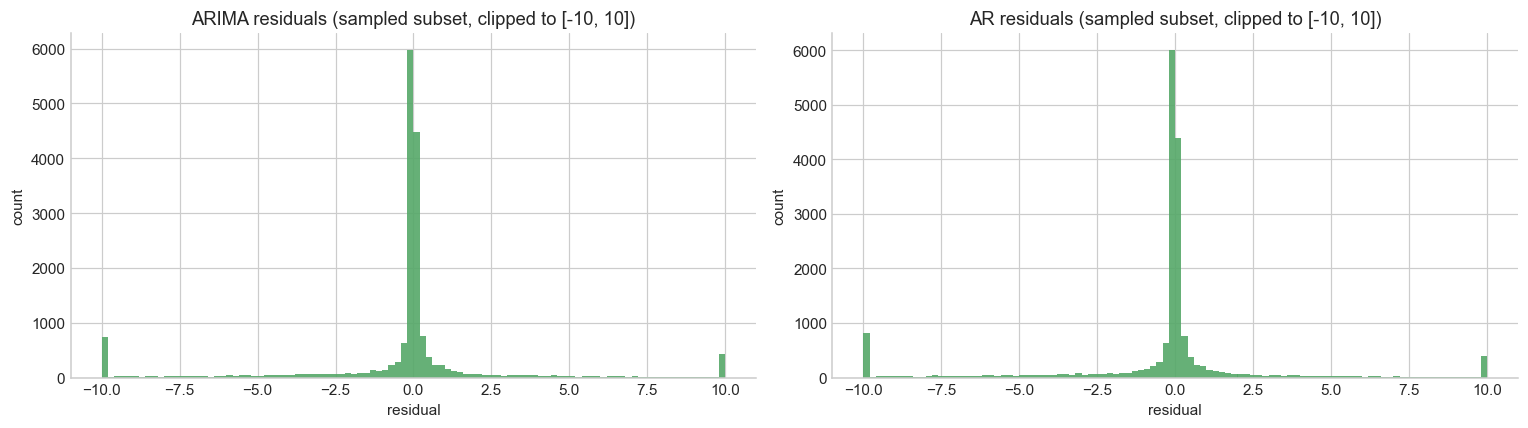

In [16]:
fig, axes = plt.subplots(1, len(top_models), figsize=(7 * len(top_models), 4))
axes = np.atleast_1d(axes)
for ax, model_name in zip(axes, top_models):
    subset = residual_df[residual_df['model'] == model_name]
    ax.hist(np.clip(subset['residual'], -10, 10), bins=100, color='#55A868', alpha=0.9)
    ax.set_title(f'{model_name} residuals (sampled subset, clipped to [-10, 10])')
    ax.set_xlabel('residual')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


## 10. Classical conclusions

The notebook should close with concise conclusions that set up the ML notebook rather than repeating every chart.


**Takeaways**

- The best classical model in this rerun establishes a meaningful baseline, but it still relies only on target history.
- Coverage and failure behavior matter almost as much as average skill: some classical models fit less consistently than others.
- Horizon growth hurts classical models, which is consistent with the target volatility seen in EDA.
- The notebook clarifies where univariate structure exists, but it also shows why the project should move to global ML models that can exploit the rich feature set and cross-series information.
